Yanuar Alvin Rifkyarthara
IK-3C/3.34.23.2.25

Jarak Euclidean antara Patch 1 dan Patch 2 : 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3 : 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2 : 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3 : 250.0000


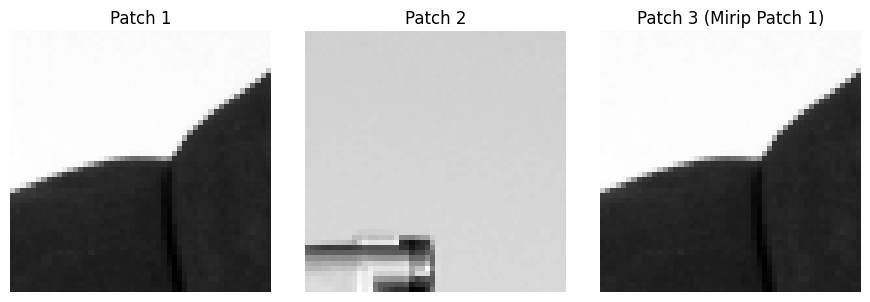

In [1]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Ambil citra asli
image = img_as_float(data.camera())

# 2. Membuat patch citra
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]   # Patch dari lokasi berbeda

# Menambahkan sedikit perubahan intensitas/noise pada patch1
patch3 = patch1 + 0.1
patch3 = np.clip(patch3, 0, 1)     # Membatasi nilai agar tetap antara 0 dan 1

# 3. Ubah patch menjadi vektor 1 dimensi
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 4. Menghitung jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 5. Menghitung jarak Manhattan (L1)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 6. Menampilkan hasil perhitungan
print(f"Jarak Euclidean antara Patch 1 dan Patch 2 : {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3 : {dist_l2_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2 : {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3 : {dist_l1_13:.4f}")

# 7. Visualisasi patch
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')

axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')

axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): 0.8156
Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): 1.0000
Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Downsampled): 1.0000


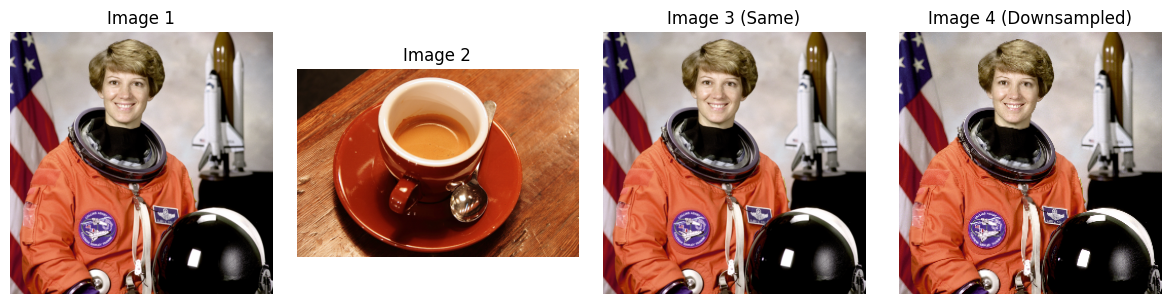

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)

    # Histogram tiap channel warna
    hist_r, _ = np.histogram(img_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))

    # Gabungkan histogram RGB menjadi satu vektor fitur
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi histogram
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)

    return hist_combined

# 1. Memuat citra berwarna
try:
    image1 = data.astronaut()
    image2 = data.coffee()          # Citra berbeda
    image3 = data.astronaut()       # Citra sama
    image4 = image1[::2, ::2, :]    # Versi downsampled

except Exception as e:
    print(f"Gagal memuat data skimage: {e}")

    # Membuat citra dummy jika gagal
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3)
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]

# 2. Menghitung histogram tiap citra
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Menghitung Cosine Similarity
# cosine() menghasilkan distance, sehingga similarity = 1 - distance
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

# 4. Menampilkan hasil
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): {sim_12:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): {sim_13:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Downsampled): {sim_14:.4f}")

# 5. Visualisasi citra
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(image1)
axes[0].set_title('Image 1')
axes[0].axis('off')

axes[1].imshow(image2)
axes[1].set_title('Image 2')
axes[1].axis('off')

axes[2].imshow(image3)
axes[2].set_title('Image 3 (Same)')
axes[2].axis('off')

axes[3].imshow(image4)
axes[3].set_title('Image 4 (Downsampled)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

SSIM (Reference vs Same)      : 1.0000
SSIM (Reference vs Noisy)     : 0.2964
SSIM (Reference vs Contrast)  : 0.9651
SSIM (Reference vs Blurred)   : 0.8027


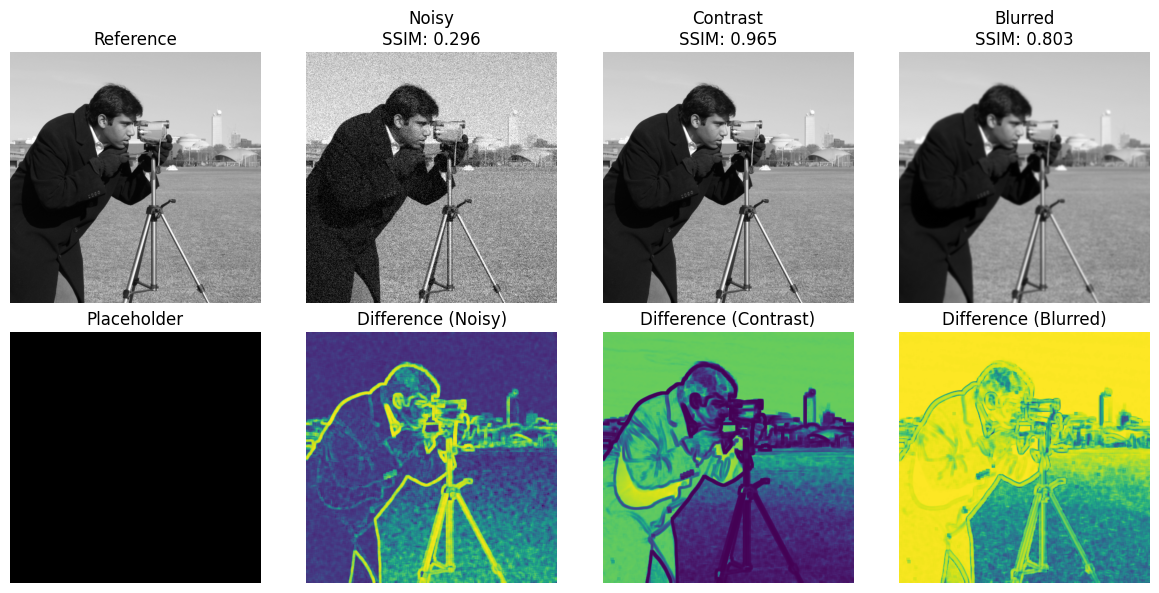

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Memuat citra referensi
image_ref = img_as_float(data.camera())

# 2. Membuat beberapa versi citra terdistorsi

# a. Citra yang sama
image_same = image_ref.copy()

# b. Citra dengan noise Gaussian
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)

# c. Citra dengan perubahan kontras
image_contrast = np.clip(image_ref * 0.8, 0, 1)

# d. Citra yang di-blur
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)

# 3. Menghitung SSIM
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(
    image_ref,
    image_same,
    data_range=data_range,
    full=True
)

ssim_noisy, diff_noisy = ssim(
    image_ref,
    image_noisy,
    data_range=data_range,
    full=True
)

ssim_contrast, diff_contrast = ssim(
    image_ref,
    image_contrast,
    data_range=data_range,
    full=True
)

ssim_blurred, diff_blurred = ssim(
    image_ref,
    image_blurred,
    data_range=data_range,
    full=True
)

# 4. Menampilkan hasil SSIM
print(f"SSIM (Reference vs Same)      : {ssim_same:.4f}")
print(f"SSIM (Reference vs Noisy)     : {ssim_noisy:.4f}")
print(f"SSIM (Reference vs Contrast)  : {ssim_contrast:.4f}")
print(f"SSIM (Reference vs Blurred)   : {ssim_blurred:.4f}")

# 5. Visualisasi hasil
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

# Baris pertama: citra hasil
ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[0].axis('off')

ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
ax[1].axis('off')

ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
ax[2].axis('off')

ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')
ax[3].axis('off')

# Baris kedua: peta perbedaan SSIM
ax[4].imshow(np.zeros_like(image_ref), cmap='gray')
ax[4].set_title('Placeholder')
ax[4].axis('off')

ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('Difference (Noisy)')
ax[5].axis('off')

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('Difference (Contrast)')
ax[6].axis('off')

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('Difference (Blurred)')
ax[7].axis('off')

plt.tight_layout()
plt.show()

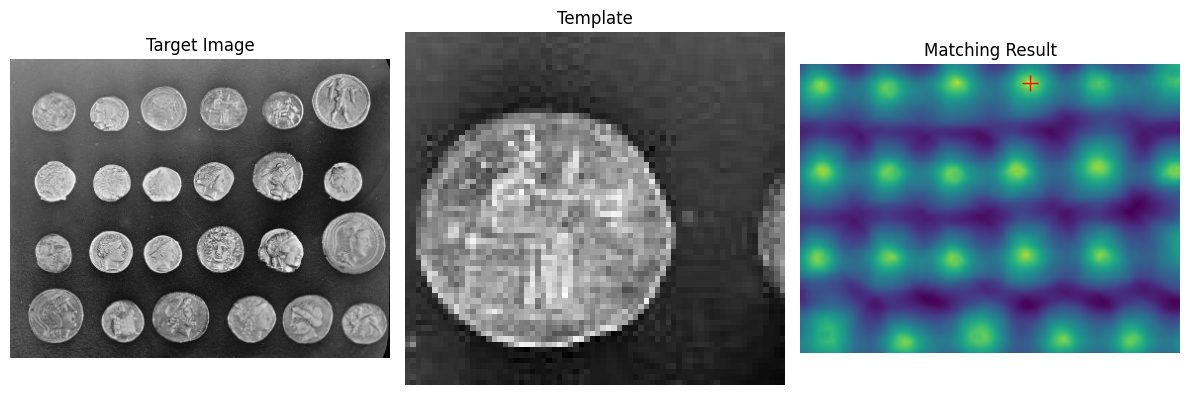

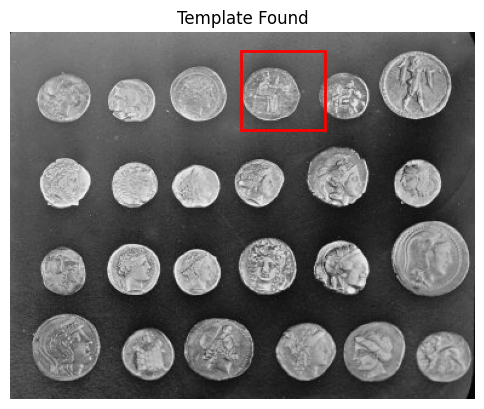

Template ditemukan di koordinat (x, y): (190, 15)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.feature import match_template

# 1. Memuat citra target
image = data.coins()

# 2. Mengambil salah satu objek sebagai template
template = image[15:80, 190:260]

# 3. Melakukan template matching
# Metode default menggunakan Normalized Cross-Correlation
result = match_template(image, template)

# 4. Menentukan lokasi dengan skor kecocokan tertinggi
ij = np.unravel_index(np.argmax(result), result.shape)

# Koordinat posisi terbaik
y, x = ij

# 5. Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Citra target
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].axis('off')

# Template
ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].axis('off')

# Heatmap hasil matching
ax[2].imshow(result, cmap='viridis')
ax[2].plot(x, y, 'r+', markersize=12)
ax[2].set_title('Matching Result')
ax[2].axis('off')

plt.tight_layout()

# 6. Menampilkan lokasi template pada citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))

ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.axis('off')

# Ukuran template
h, w = template.shape

# Membuat kotak penanda
rect = plt.Rectangle(
    (x, y),
    w,
    h,
    edgecolor='red',
    facecolor='none',
    linewidth=2
)

ax_main.add_patch(rect)

plt.show()

# 7. Menampilkan koordinat hasil pencocokan
print(f"Template ditemukan di koordinat (x, y): ({x}, {y})")

Memproses database citra...
- astronaut berhasil diproses
- camera berhasil diproses
- coffee berhasil diproses
- coins berhasil diproses
- chelsea berhasil diproses

Hasil Retrieval:
(Semakin kecil distance, semakin mirip)

Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


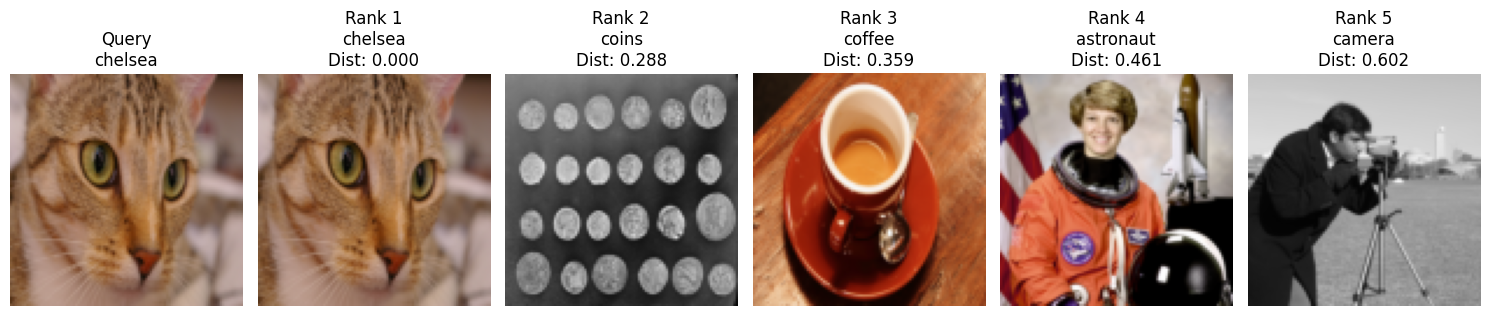

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

# Fungsi menghitung histogram RGB
def calculate_rgb_histogram(image, bins=16):

    # Konversi ke uint8 jika bertipe float
    if image.dtype == float:
        image = img_as_ubyte(image)

    # Histogram tiap channel RGB
    hist_r, _ = np.histogram(
        image[:, :, 0].ravel(),
        bins=bins,
        range=(0, 256)
    )

    hist_g, _ = np.histogram(
        image[:, :, 1].ravel(),
        bins=bins,
        range=(0, 256)
    )

    hist_b, _ = np.histogram(
        image[:, :, 2].ravel(),
        bins=bins,
        range=(0, 256)
    )

    # Gabungkan histogram
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi histogram
    hist_sum = np.sum(hist_combined)

    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)

    return hist_combined

# 1. Membuat database citra
image_db_names = [
    "astronaut",
    "camera",
    "coffee",
    "coins",
    "chelsea"
]

database_images = []
database_hists = []

print("Memproses database citra...")

for name in image_db_names:
    try:
        # Memuat citra dari skimage
        img = getattr(data, name)()

        # Jika grayscale, ubah ke RGB
        if img.ndim == 2:
            img = color.gray2rgb(img)

        # Resize agar ukuran konsisten
        img_resized = transform.resize(
            img,
            (100, 100),
            anti_aliasing=True
        )

        # Simpan citra dan histogram
        database_images.append(img_resized)
        database_hists.append(
            calculate_rgb_histogram(img_resized)
        )

        print(f"- {name} berhasil diproses")

    except Exception as e:
        print(f"Error memproses {name}: {e}")

# 2. Menentukan citra query
query_image_name = "chelsea"

query_index = image_db_names.index(query_image_name)

query_image = database_images[query_index]
query_hist = database_hists[query_index]

# 3. Menghitung cosine distance
distances = []

for hist in database_hists:
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

# 4. Mengurutkan hasil berdasarkan jarak terkecil
sorted_indices = np.argsort(distances)

# 5. Visualisasi hasil retrieval
num_results = len(database_images)

fig, axes = plt.subplots(
    1,
    num_results + 1,
    figsize=(15, 3)
)

# Menampilkan query image
axes[0].imshow(query_image)
axes[0].set_title(f"Query\n{query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval:")
print("(Semakin kecil distance, semakin mirip)\n")

# Menampilkan hasil ranking
for i, idx in enumerate(sorted_indices):

    rank = i + 1

    axes[rank].imshow(database_images[idx])

    axes[rank].set_title(
        f"Rank {rank}\n"
        f"{image_db_names[idx]}\n"
        f"Dist: {distances[idx]:.3f}"
    )

    axes[rank].axis('off')

    print(
        f"Rank {rank}: "
        f"{image_db_names[idx]} "
        f"(Distance: {distances[idx]:.3f})"
    )

plt.tight_layout()
plt.show()

SOAL NOMOR 3


Memproses database citra...

astronaut berhasil diproses
camera berhasil diproses
coffee berhasil diproses
coins berhasil diproses
chelsea berhasil diproses

Hasil Retrieval:
(Semakin kecil distance, semakin mirip)

Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


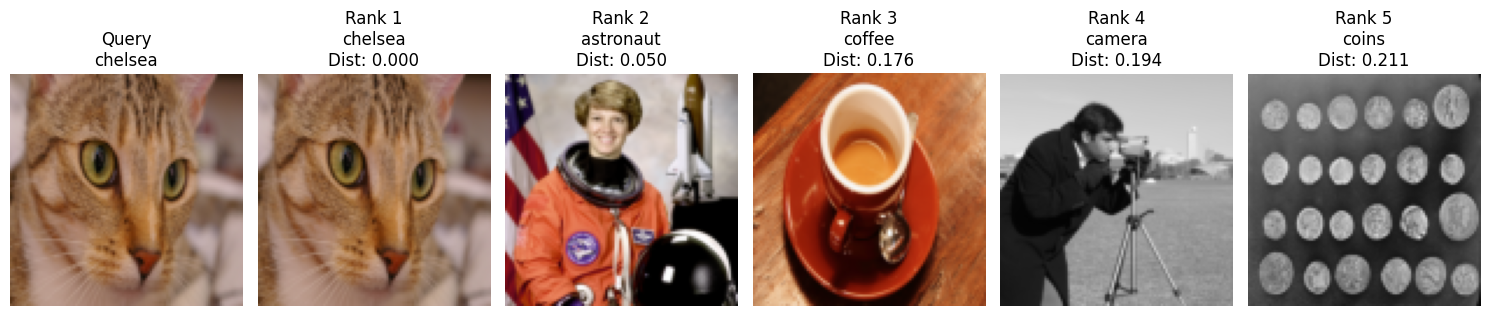

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, color, transform
from scipy.spatial import distance

# =====================================================
# Fungsi fitur rata-rata warna RGB
# =====================================================
def calculate_mean_rgb(image):

    # Hitung rata-rata tiap channel RGB
    mean_r = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_b = np.mean(image[:, :, 2])

    # Gabungkan menjadi vektor fitur
    feature_vector = np.array([mean_r, mean_g, mean_b])

    return feature_vector


# =====================================================
# 1. Membuat database citra
# =====================================================
image_db_names = [
    "astronaut",
    "camera",
    "coffee",
    "coins",
    "chelsea"
]

database_images = []
database_features = []

print("Memproses database citra...\n")

for name in image_db_names:

    try:
        # Memuat citra
        img = getattr(data, name)()

        # Jika grayscale -> ubah ke RGB
        if img.ndim == 2:
            img = color.gray2rgb(img)

        # Resize agar ukuran konsisten
        img_resized = transform.resize(
            img,
            (100, 100),
            anti_aliasing=True
        )

        # Simpan citra
        database_images.append(img_resized)

        # Hitung fitur mean RGB
        feature = calculate_mean_rgb(img_resized)

        database_features.append(feature)

        print(f"{name} berhasil diproses")

    except Exception as e:
        print(f"Error memproses {name}: {e}")


# =====================================================
# 2. Menentukan citra query
# =====================================================
query_image_name = "chelsea"

query_index = image_db_names.index(query_image_name)

query_image = database_images[query_index]
query_feature = database_features[query_index]


# =====================================================
# 3. Menghitung Euclidean Distance
# =====================================================
distances = []

for feature in database_features:

    dist = distance.euclidean(
        query_feature,
        feature
    )

    distances.append(dist)


# =====================================================
# 4. Mengurutkan hasil retrieval
# =====================================================
sorted_indices = np.argsort(distances)


# =====================================================
# 5. Visualisasi hasil
# =====================================================
num_results = len(database_images)

fig, axes = plt.subplots(
    1,
    num_results + 1,
    figsize=(15, 3)
)

# Query image
axes[0].imshow(query_image)
axes[0].set_title(f"Query\n{query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval:")
print("(Semakin kecil distance, semakin mirip)\n")

# Hasil ranking
for i, idx in enumerate(sorted_indices):

    rank = i + 1

    axes[rank].imshow(database_images[idx])

    axes[rank].set_title(
        f"Rank {rank}\n"
        f"{image_db_names[idx]}\n"
        f"Dist: {distances[idx]:.3f}"
    )

    axes[rank].axis('off')

    print(
        f"Rank {rank}: "
        f"{image_db_names[idx]} "
        f"(Distance: {distances[idx]:.3f})"
    )

plt.tight_layout()
plt.show()

SOAL NOMOR 4


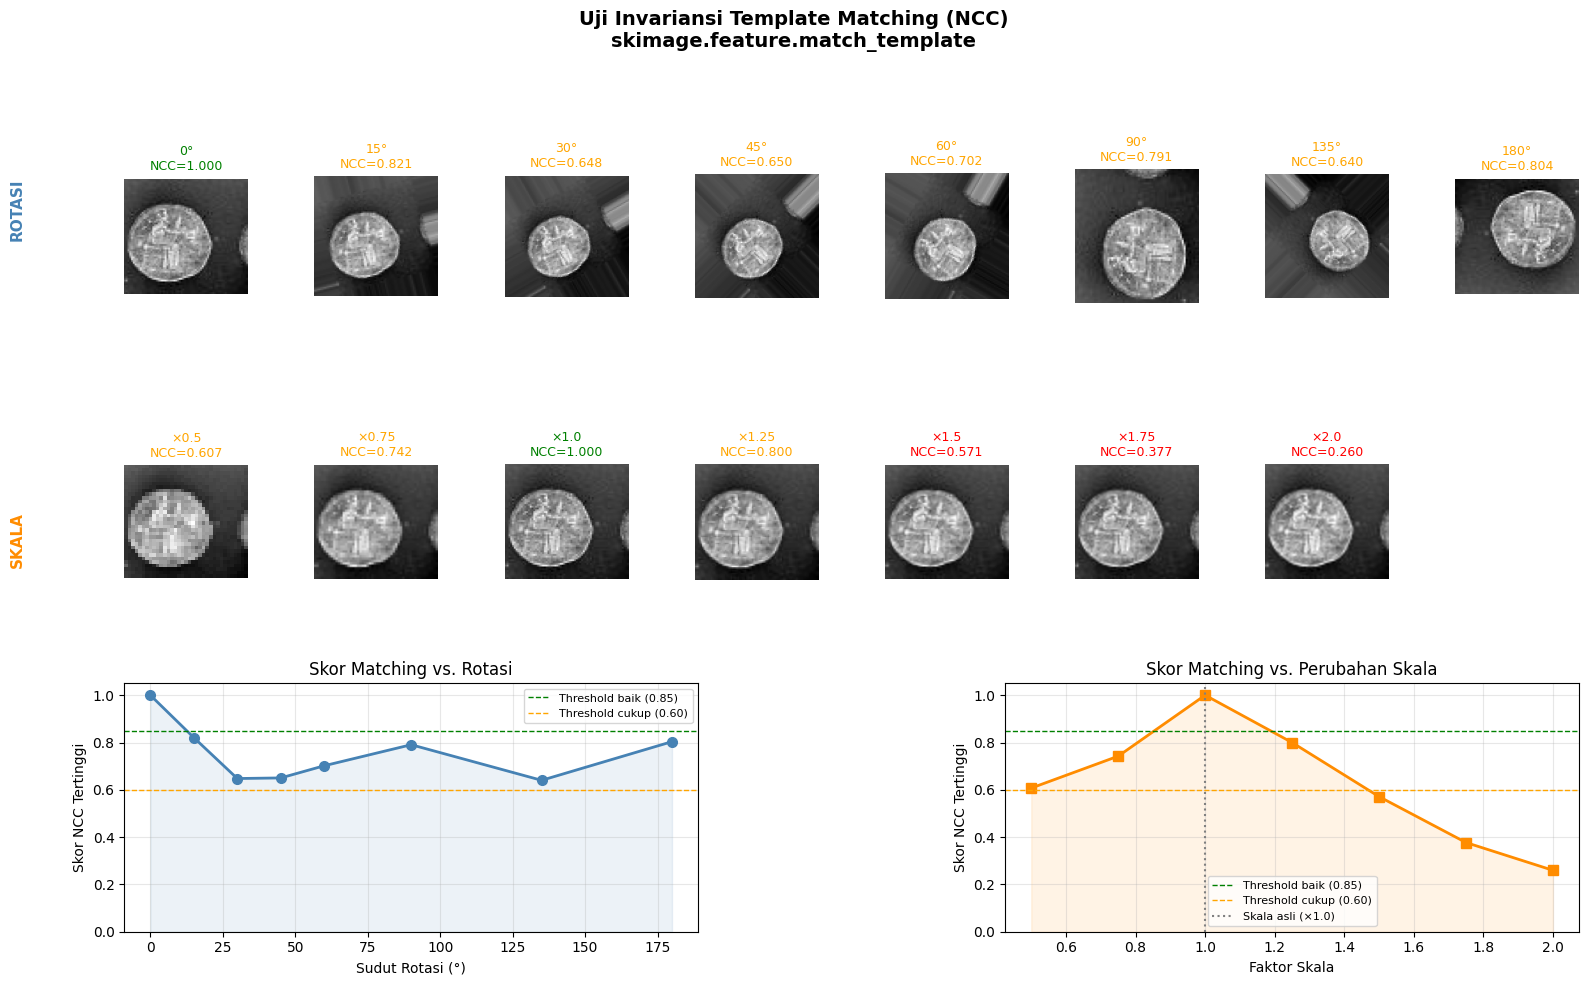

HASIL UJI ROTASI
  Rotasi    0° → NCC = 1.0000  ✅ BAGUS
  Rotasi   15° → NCC = 0.8206  ⚠️ CUKUP
  Rotasi   30° → NCC = 0.6477  ⚠️ CUKUP
  Rotasi   45° → NCC = 0.6502  ⚠️ CUKUP
  Rotasi   60° → NCC = 0.7018  ⚠️ CUKUP
  Rotasi   90° → NCC = 0.7907  ⚠️ CUKUP
  Rotasi  135° → NCC = 0.6401  ⚠️ CUKUP
  Rotasi  180° → NCC = 0.8036  ⚠️ CUKUP

HASIL UJI PERUBAHAN SKALA
  Skala ×0.50 → NCC = 0.6074  ⚠️ CUKUP
  Skala ×0.75 → NCC = 0.7423  ⚠️ CUKUP
  Skala ×1.00 → NCC = 1.0000  ✅ BAGUS
  Skala ×1.25 → NCC = 0.7999  ⚠️ CUKUP
  Skala ×1.50 → NCC = 0.5712  ❌ BURUK
  Skala ×1.75 → NCC = 0.3771  ❌ BURUK
  Skala ×2.00 → NCC = 0.2597  ❌ BURUK

KESIMPULAN:
- Rotasi  : Skor turun drastis sejak ~15-30°  → TIDAK invariant terhadap rotasi
- Skala   : Skor turun jika skala ≠ 1.0       → TIDAK invariant terhadap skala
- Skala ×1.0 (asli) menghasilkan skor tertinggi (~1.0)



In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from skimage.feature import match_template

# ─────────────────────────────────────────────
# 1. Setup: Citra target & template original
# ─────────────────────────────────────────────
image    = data.coins()
template = image[15:80, 190:260]   # Template koin asli (sama seperti Praktikum 4)

def best_match_score(img, tmpl):
    """Kembalikan skor NCC tertinggi dari hasil matching."""
    result = match_template(img, tmpl)
    return result.max(), np.unravel_index(np.argmax(result), result.shape)

# ─────────────────────────────────────────────
# 2. EKSPERIMEN A — Template DIROTASI
# ─────────────────────────────────────────────
angles       = [0, 15, 30, 45, 60, 90, 135, 180]
scores_rot   = []
templates_rot = []

for angle in angles:
    # rotate: resize=True agar template tidak terpotong, mode='edge' untuk padding
    t_rot = transform.rotate(template.astype(float), angle,
                             resize=True, mode='edge', preserve_range=True)
    t_rot = t_rot.astype(np.uint8)
    score, _ = best_match_score(image, t_rot)
    scores_rot.append(score)
    templates_rot.append(t_rot)

# ─────────────────────────────────────────────
# 3. EKSPERIMEN B — Template DIUBAH SKALA
# ─────────────────────────────────────────────
scale_factors = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
scores_scale  = []
templates_sc  = []

h0, w0 = template.shape
for sf in scale_factors:
    new_h, new_w = max(2, int(h0 * sf)), max(2, int(w0 * sf))
    t_sc = transform.resize(template.astype(float), (new_h, new_w),
                            preserve_range=True, anti_aliasing=True).astype(np.uint8)
    # Lewati jika template lebih besar dari citra
    if t_sc.shape[0] >= image.shape[0] or t_sc.shape[1] >= image.shape[1]:
        scores_scale.append(np.nan)
    else:
        score, _ = best_match_score(image, t_sc)
        scores_scale.append(score)
    templates_sc.append(t_sc)

# ─────────────────────────────────────────────
# 4. VISUALISASI HASIL
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Uji Invariansi Template Matching (NCC)\nskimage.feature.match_template',
             fontsize=14, fontweight='bold')

# — Baris 1: Template yang dirotasi —
n_rot = len(angles)
for i, (angle, tmpl, score) in enumerate(zip(angles, templates_rot, scores_rot)):
    ax = fig.add_subplot(3, max(n_rot, len(scale_factors)), i + 1)
    ax.imshow(tmpl, cmap='gray')
    color = 'green' if score > 0.85 else ('orange' if score > 0.6 else 'red')
    ax.set_title(f'{angle}°\nNCC={score:.3f}', fontsize=9, color=color)
    ax.axis('off')

# Label baris kiri
fig.text(0.01, 0.78, 'ROTASI', va='center', rotation='vertical',
         fontsize=11, fontweight='bold', color='steelblue')

# — Baris 2: Template yang diubah skala —
n_sc = len(scale_factors)
for i, (sf, tmpl, score) in enumerate(zip(scale_factors, templates_sc, scores_scale)):
    ax = fig.add_subplot(3, max(n_rot, n_sc), n_rot + i + 1)
    ax.imshow(tmpl, cmap='gray')
    lbl = f'nan' if np.isnan(score) else f'{score:.3f}'
    color = 'green' if (not np.isnan(score) and score > 0.85) else \
            ('orange' if (not np.isnan(score) and score > 0.6) else 'red')
    ax.set_title(f'×{sf}\nNCC={lbl}', fontsize=9, color=color)
    ax.axis('off')

fig.text(0.01, 0.45, 'SKALA', va='center', rotation='vertical',
         fontsize=11, fontweight='bold', color='darkorange')

# — Baris 3: Grafik skor —
# Grafik rotasi
ax_gr = fig.add_subplot(3, 2, 5)
ax_gr.plot(angles, scores_rot, 'o-', color='steelblue', linewidth=2, markersize=7)
ax_gr.axhline(0.85, color='green', linestyle='--', linewidth=1, label='Threshold baik (0.85)')
ax_gr.axhline(0.60, color='orange', linestyle='--', linewidth=1, label='Threshold cukup (0.60)')
ax_gr.fill_between(angles, scores_rot, 0, alpha=0.1, color='steelblue')
ax_gr.set_xlabel('Sudut Rotasi (°)')
ax_gr.set_ylabel('Skor NCC Tertinggi')
ax_gr.set_title('Skor Matching vs. Rotasi')
ax_gr.set_ylim(0, 1.05)
ax_gr.legend(fontsize=8)
ax_gr.grid(True, alpha=0.3)

# Grafik skala
ax_gs = fig.add_subplot(3, 2, 6)
valid_scores = [s if not np.isnan(s) else 0 for s in scores_scale]
ax_gs.plot(scale_factors, valid_scores, 's-', color='darkorange', linewidth=2, markersize=7)
ax_gs.axhline(0.85, color='green', linestyle='--', linewidth=1, label='Threshold baik (0.85)')
ax_gs.axhline(0.60, color='orange', linestyle='--', linewidth=1, label='Threshold cukup (0.60)')
ax_gs.axvline(1.0, color='gray', linestyle=':', linewidth=1.5, label='Skala asli (×1.0)')
ax_gs.fill_between(scale_factors, valid_scores, 0, alpha=0.1, color='darkorange')
ax_gs.set_xlabel('Faktor Skala')
ax_gs.set_ylabel('Skor NCC Tertinggi')
ax_gs.set_title('Skor Matching vs. Perubahan Skala')
ax_gs.set_ylim(0, 1.05)
ax_gs.legend(fontsize=8)
ax_gs.grid(True, alpha=0.3)

plt.tight_layout(rect=[0.04, 0, 1, 0.95])
plt.show()

# ─────────────────────────────────────────────
# 5. RINGKASAN HASIL DI KONSOL
# ─────────────────────────────────────────────
print("=" * 50)
print("HASIL UJI ROTASI")
print("=" * 50)
for angle, score in zip(angles, scores_rot):
    status = "✅ BAGUS" if score > 0.85 else ("⚠️ CUKUP" if score > 0.6 else "❌ BURUK")
    print(f"  Rotasi {angle:>4}° → NCC = {score:.4f}  {status}")

print("\n" + "=" * 50)
print("HASIL UJI PERUBAHAN SKALA")
print("=" * 50)
for sf, score in zip(scale_factors, scores_scale):
    if np.isnan(score):
        print(f"  Skala ×{sf} → Template terlalu besar (dilewati)")
    else:
        status = "✅ BAGUS" if score > 0.85 else ("⚠️ CUKUP" if score > 0.6 else "❌ BURUK")
        print(f"  Skala ×{sf:.2f} → NCC = {score:.4f}  {status}")

print("""
KESIMPULAN:
- Rotasi  : Skor turun drastis sejak ~15-30°  → TIDAK invariant terhadap rotasi
- Skala   : Skor turun jika skala ≠ 1.0       → TIDAK invariant terhadap skala
- Skala ×1.0 (asli) menghasilkan skor tertinggi (~1.0)
""")